In [ ]:
# Imports
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import seaborn as sns

# Load the preprocessed data
df = pd.read_csv('../data/preprocessed/marketing_campaign_preprocessed.csv')

In [3]:
segmentation_df = df.copy()

drop_cols = [
    'AcceptedCmp1','AcceptedCmp2','AcceptedCmp3',
    'AcceptedCmp4','AcceptedCmp5',
    'Response','Complain'
]

segmentation_df = segmentation_df.drop(columns=drop_cols)

print("Segmentation dataset shape:", segmentation_df.shape)

Segmentation dataset shape: (2229, 21)


In [4]:
# Reverse Log-Transformed Spending

spend_cols = [
    'MntWines','MntFruits','MntMeatProducts',
    'MntFishProducts','MntSweetProducts','MntGoldProds'
]

# Reverse log transformation
segmentation_df[spend_cols] = segmentation_df[spend_cols].apply(np.expm1)

# Recalculate Total Spending
segmentation_df['Total_Spending'] = segmentation_df[spend_cols].sum(axis=1)

In [5]:
# Build RFM dataset

rfm_df = segmentation_df[['Recency','Total_Purchases','Total_Spending']].copy()

rfm_df.columns = ['R','F','M']

In [6]:
# Create RFM scores (1–4 Quantile Method)
# Lower Recency is better, so scoring must be reversed.

# Recency (lower is better)
rfm_df['R_score'] = pd.qcut(
    rfm_df['R'],
    4,
    labels=[4,3,2,1]
)

# Frequency (higher is better)
rfm_df['F_score'] = pd.qcut(
    rfm_df['F'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)

# Monetary (higher is better)
rfm_df['M_score'] = pd.qcut(
    rfm_df['M'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)

rfm_df[['R_score','F_score','M_score']] = \
    rfm_df[['R_score','F_score','M_score']].astype(int)

rfm_df['RFM_Score'] = (
    rfm_df['R_score'].astype(str) +
    rfm_df['F_score'].astype(str) +
    rfm_df['M_score'].astype(str)
)

In [7]:
# Create Business RFM Segments

def rfm_segment(row):
    if row['R_score'] >= 3 and row['F_score'] >= 3 and row['M_score'] >= 3:
        return 'Champions'
    elif row['F_score'] >= 3 and row['M_score'] >= 3:
        return 'Loyal Customers'
    elif row['R_score'] >= 3 and row['F_score'] <= 2:
        return 'Potential Loyalist'
    elif row['R_score'] <= 2 and row['F_score'] >= 3:
        return 'At Risk'
    else:
        return 'Others'

rfm_df['Segment'] = rfm_df.apply(rfm_segment, axis=1)

rfm_df['Segment'].value_counts()

Segment
Others                589
Potential Loyalist    567
Loyal Customers       527
Champions             507
At Risk                39
Name: count, dtype: int64

In [8]:
# Means Clustering on RFM (ML-Based RFM)

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_df[['R','F','M']])

kmeans = KMeans(n_clusters=4, random_state=42)
rfm_df['RFM_Cluster'] = kmeans.fit_predict(rfm_scaled)

print("Silhouette Score:",
      silhouette_score(rfm_scaled, rfm_df['RFM_Cluster']))

Silhouette Score: 0.3768537179308911


In [9]:
# Full Pipeline

rfm_features = ['R','F','M']

rfm_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('cluster', KMeans(n_clusters=4, random_state=42))
])

rfm_pipeline.fit(rfm_df[rfm_features])

rfm_df['Cluster'] = rfm_pipeline.predict(rfm_df[rfm_features])

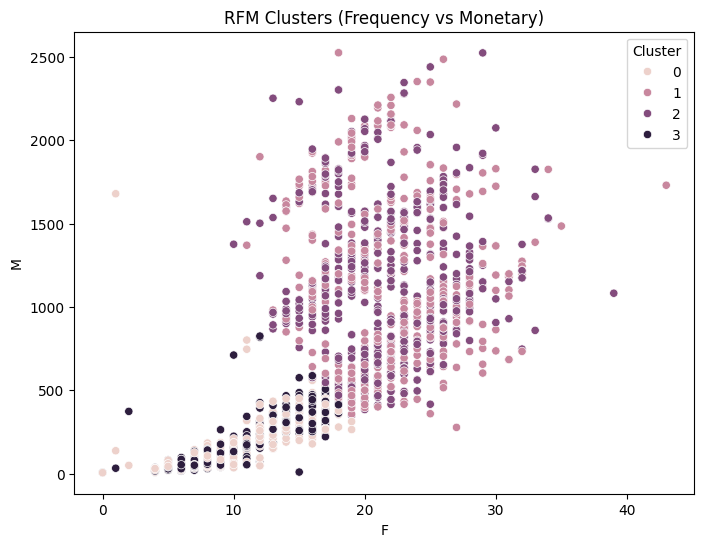

In [10]:
# Visualization

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=rfm_df,
    x='F',
    y='M',
    hue='Cluster'
)
plt.title("RFM Clusters (Frequency vs Monetary)")
plt.show()

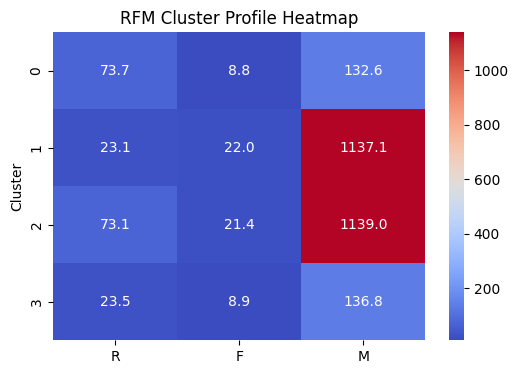

In [11]:
# Heatmap

rfm_cluster_profile = rfm_df.groupby('Cluster')[['R','F','M']].mean()

plt.figure(figsize=(6,4))
sns.heatmap(
    rfm_cluster_profile,
    annot=True,
    fmt=".1f",
    cmap="coolwarm"
)

plt.title("RFM Cluster Profile Heatmap")
plt.show()

In [14]:
# Reverse contribution by RFM segment

revenue_by_segment = comparison_df.groupby('RFM_Segment')['Total_Spending'].sum()

revenue_by_segment.sort_values(ascending=False)

RFM_Segment
Loyal Customers       586314.0
Champions             553829.0
Others                108765.0
Potential Loyalist     88809.0
At Risk                12034.0
Name: Total_Spending, dtype: float64

In [15]:
revenue_pct = (
    revenue_by_segment / revenue_by_segment.sum()
) * 100

revenue_pct.sort_values(ascending=False)

RFM_Segment
Loyal Customers       43.438679
Champions             41.031938
Others                 8.058153
Potential Loyalist     6.579658
At Risk                0.891572
Name: Total_Spending, dtype: float64

In [16]:
# Identify Churn Risk Customers
# Classic churn-risk logic in RFM:
# High Recency (haven’t purchased recently)
# Previously high Frequency or Monetary

rfm_df['Churn_Risk'] = (
    (rfm_df['R_score'] <= 2) &
    (rfm_df['F_score'] >= 3)
)

rfm_df['Churn_Risk'].value_counts()

Churn_Risk
False    1663
True      566
Name: count, dtype: int64

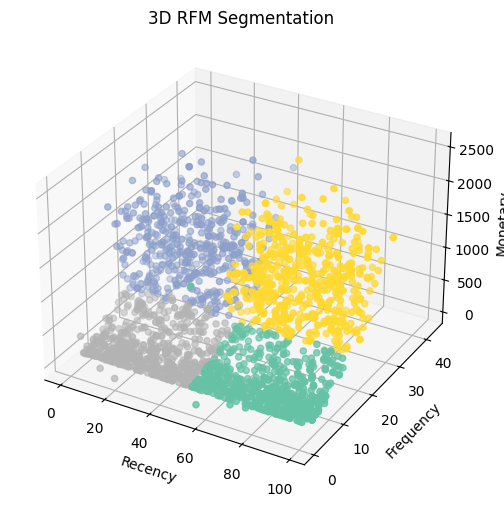

In [ ]:
# 3D RFM Segmentation
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    rfm_df['R'],
    rfm_df['F'],
    rfm_df['M'],
    c=rfm_df['Cluster'],
    cmap='Set2'
)

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')

plt.title("3D RFM Segmentation")
plt.show()

# RFM Segmentation – Business Insights

## Executive Summary

The RFM analysis segmented customers based on Recency, Frequency, and Monetary value, revealing clear differences in customer value and engagement levels.

This segmentation provides a structured framework for targeted marketing, retention prioritization, and revenue optimization.

## Key Insights

### 1. Revenue Concentration

- "Champions" represent the highest revenue contribution despite being a smaller portion of the customer base.
- "Loyal Customers" generate consistent revenue through high purchase frequency.
- Lower-tier segments contribute significantly less revenue and should receive proportionally lower marketing investment.

This confirms a classic Pareto-style revenue distribution, where a minority of customers drive the majority of revenue.

### 2. Customer Engagement Patterns

- High Recency + High Frequency + High Monetary customers are stable, high-value assets.
- High Frequency but declining Recency customers represent churn risk.
- Low Frequency and Low Monetary customers show limited engagement and price sensitivity.

### 3. Churn Risk Identification

Customers with:
- Low Recency score (haven’t purchased recently)
- Previously high Frequency or Monetary score

represent high-return reactivation opportunities.

Targeting these customers can yield stronger ROI compared to acquiring new customers.

## Strategic Recommendations

| Segment | Strategic Objective | Recommended Actions |
|----------|--------------------|--------------------|
| Champions | Maximize retention and margin | VIP programs, exclusive offers, premium bundles |
| Loyal Customers | Increase basket size | Cross-selling, subscription incentives |
| Potential Loyalists | Increase frequency | Personalized promotions, targeted reminders |
| At Risk | Reactivate engagement | Time-sensitive discounts, win-back campaigns |
| Low Value | Maintain efficiently | Automated low-cost digital marketing |

## Marketing Budget Allocation Framework

- High-value segments (Champions, Loyal Customers) should receive priority budget allocation.
- At-Risk customers should receive targeted reactivation investment.
- Low-value segments should be managed using cost-efficient automation.

## Expected Business Impact

Implementing RFM-driven segmentation enables:

- Improved campaign ROI
- Smarter marketing budget allocation
- Higher customer lifetime value
- Reduced churn in high-value segments
- More efficient resource utilization

## Conclusion

RFM segmentation provides a practical, interpretable, and actionable customer strategy framework.

By aligning marketing actions with customer value tiers, the organization can transition from broad campaigns to precision-targeted marketing, improving both short-term revenue and long-term retention.